In [2]:
#Part a) EDA
# i)
import pandas as pd
import matplotlib.pyplot as plt
data_path="Concrete_Data_Yeh.csv"
df = pd.read_csv(data_path)
print (f"Shape: {df.shape}")
print (f"Data types:\n{df.dtypes}")
print ("\n ================= Describe =================\n")
print(df.describe())



Shape: (1030, 9)
Data types:
cement              float64
slag                float64
flyash              float64
water               float64
superplasticizer    float64
coarseaggregate     float64
fineaggregate       float64
age                   int64
csMPa               float64
dtype: object

 ================= Describe =================

            cement         slag       flyash        water  superplasticizer  \
count  1030.000000  1030.000000  1030.000000  1030.000000       1030.000000   
mean    281.167864    73.895825    54.188350   181.567282          6.204660   
std     104.506364    86.279342    63.997004    21.354219          5.973841   
min     102.000000     0.000000     0.000000   121.800000          0.000000   
25%     192.375000     0.000000     0.000000   164.900000          0.000000   
50%     272.900000    22.000000     0.000000   185.000000          6.400000   
75%     350.000000   142.950000   118.300000   192.000000         10.200000   
max     540.000000   359.

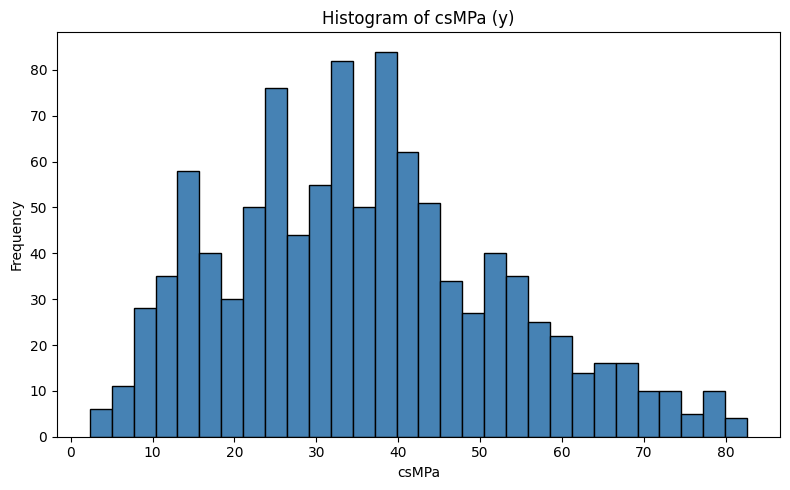

y mean: 35.82
y standard deviation: 16.71
Skewness: 0.4170


In [3]:
# ii) 
plt.figure(figsize=(8, 5))
plt.hist(df['csMPa'], bins=30, color='steelblue', edgecolor='black')
plt.title('Histogram of csMPa (y)')
plt.xlabel('csMPa')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
print(f"y mean: {df['csMPa'].mean():.2f}")
print(f"y standard deviation: {df['csMPa'].std():.2f}")
print(f"Skewness: {df['csMPa'].skew():.4f}")

The distribution is right-skewed

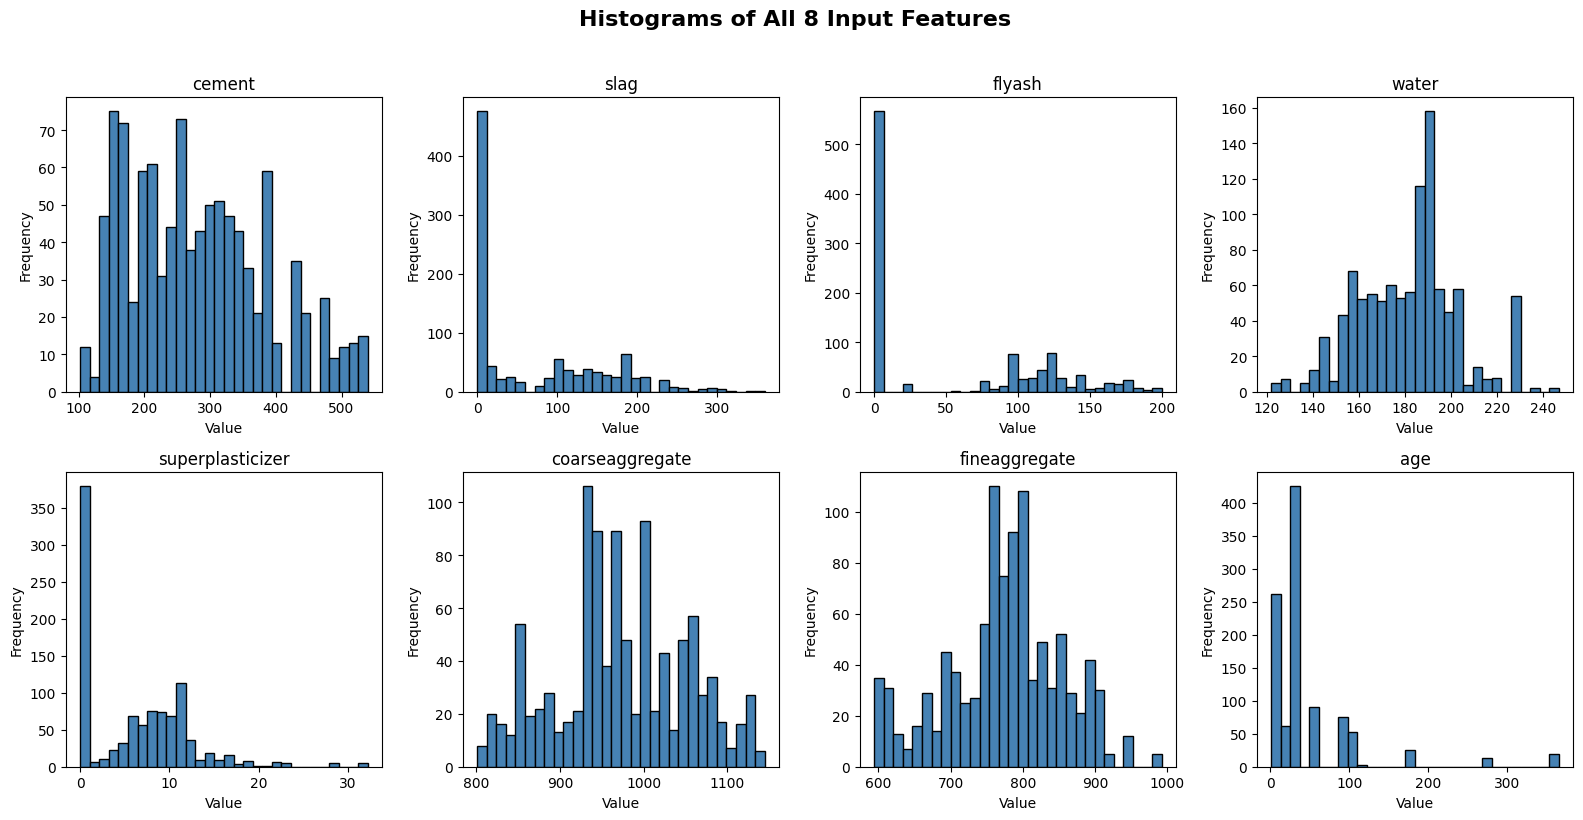

In [4]:
# iii)
input_features = df.columns[:8].tolist()  # first 8 columns as input features

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()  # flatten to 1D array for easy iteration

for i, feature in enumerate(input_features):
    axes[i].hist(df[feature], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(feature, fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Histograms of All 8 Input Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Slag, age, flyash, and superplasticizer are the most heavily skewed features. That likely happens because those are not core ingredients of croncrete and are only added in a small percentage of the mixtures, which greatly increases the frequency of 0's. For age, there is a heavy preference for small values which makes it very right skewed.
  

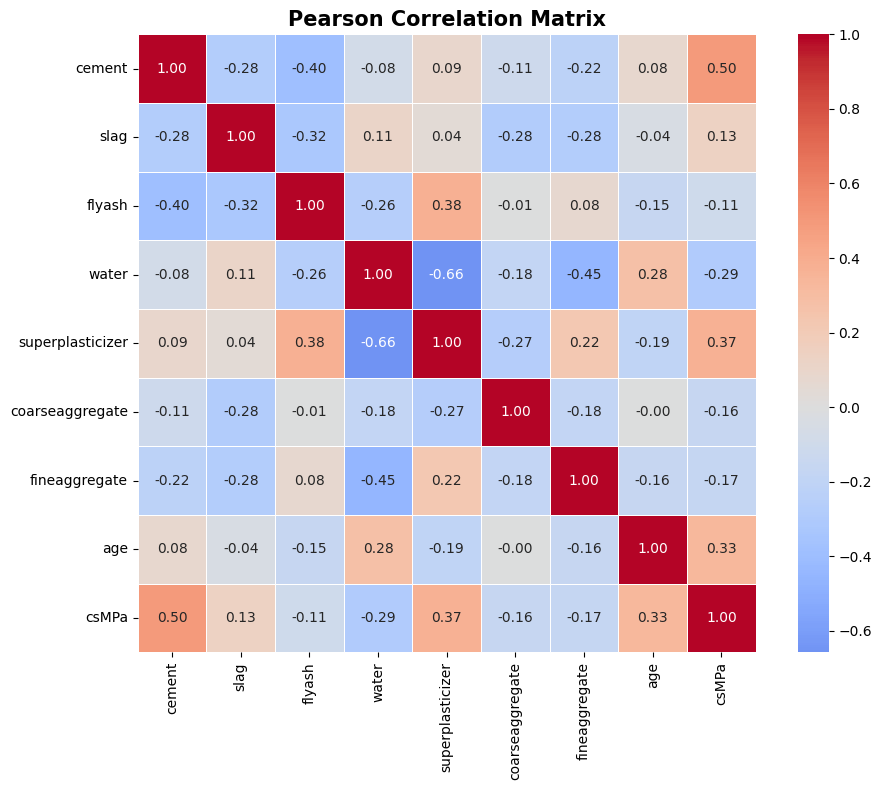

Correlations with csMPa:
cement              0.497832
superplasticizer    0.366079
age                 0.328873
slag                0.134829
flyash             -0.105755
coarseaggregate    -0.164935
fineaggregate      -0.167241
water              -0.289633
Name: csMPa, dtype: float64

Most POSITIVELY correlated: cement (0.4978)
Most NEGATIVELY correlated: water (-0.2896)


In [5]:
# iv)
import seaborn as sns

# Compute Pearson correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Pearson Correlation Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Most positively and negatively correlated with target (CSMPA)
target = 'csMPa'
correlations = corr_matrix[target].drop(target).sort_values(ascending=False)

print("Correlations with csMPa:")
print(correlations)
print(f"\nMost POSITIVELY correlated: {correlations.idxmax()} ({correlations.max():.4f})")
print(f"Most NEGATIVELY correlated: {correlations.idxmin()} ({correlations.min():.4f})")

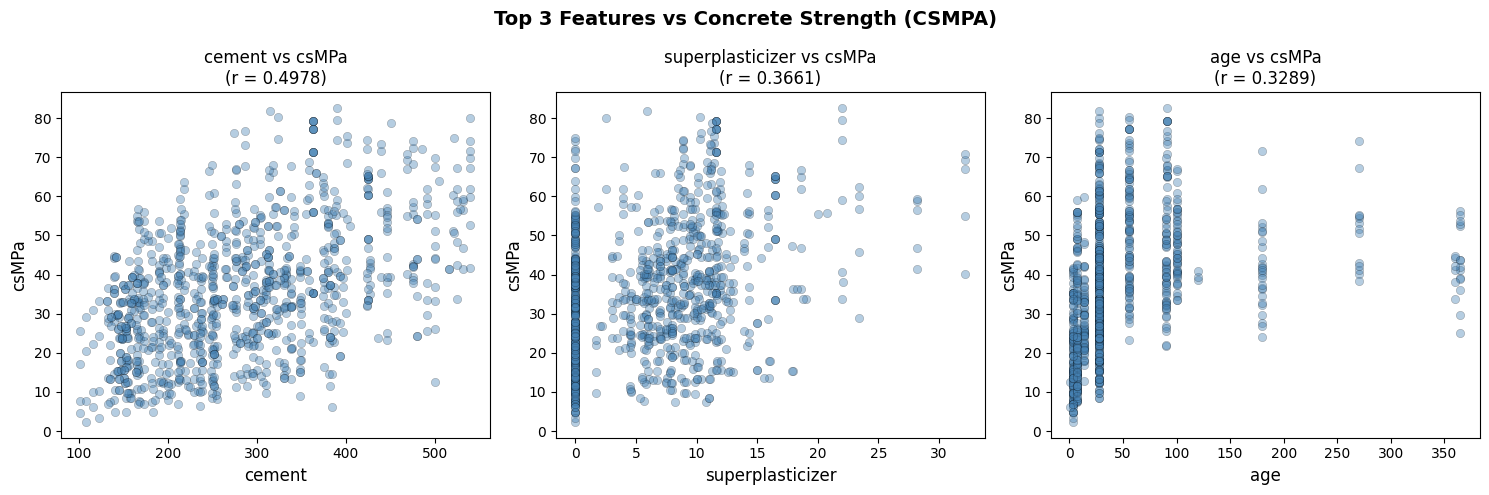

In [6]:
# v)

#Take absolute values, sort them and get the top 3
top3_features = corr_matrix[target].drop(target).abs().sort_values(ascending=False).head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feature in enumerate(top3_features):
    corr_val = corr_matrix[target][feature]
    axes[i].scatter(df[feature], df[target], alpha=0.4, color='steelblue', edgecolors='k', linewidths=0.3)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel(target, fontsize=12)
    axes[i].set_title(f'{feature} vs {target}\n(r = {corr_val:.4f})', fontsize=12)

plt.suptitle('Top 3 Features vs Concrete Strength (CSMPA)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The relationships do not look linear in general, although cement is the closest one to a line

In [7]:
# Part b)
# i)
from sklearn.model_selection import train_test_split
import numpy as np

np.random.seed(42)

# Define features (X) and target (y)
X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total samples:      {len(df)}")
print(f"Training samples:   {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test samples:       {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")


Total samples:      1030
Training samples:   824 (80.0%)
Test samples:       206 (20.0%)


ii) Our features have very different units and orders of magnitude. For example, cement, superplasticizer, and age have different units (days x kg/m^3) and cement is usually 10x larger than surperplasticizer, which confuses the model and slows down optimization. Standardization uses mean and variance to get a measurement of how each feature point compares to the average of that specific feature, which makes changes comparable between different features.

In [8]:
# iii)
for feature in X.columns:
    mean = X_train[feature].mean()
    std = X_train[feature].std()
    X_train[feature] = (X_train[feature] - mean) / std
    X_test[feature] = (X_test[feature] - mean) / std

We use mean and standard deviation of training only to avoid data leakage. In other words, including test in the computation would give our model information about future data, which makes it unrealisticly better.

In [9]:
# iv)
print("===Training mean and std after standardization:===")
for feature in X.columns:
    new_mean = X_train[feature].mean()
    new_std = X_train[feature].std()
    print (f"{feature}: mean={new_mean:.4f}, std={new_std:.4f}")

print("\n\n===Test mean and std after standardization:===")
for feature in X.columns:
    new_mean = X_test[feature].mean()
    new_std = X_test[feature].std()
    print (f"{feature}: mean={new_mean:.4f}, std={new_std:.4f}")

===Training mean and std after standardization:===
cement: mean=0.0000, std=1.0000
slag: mean=0.0000, std=1.0000
flyash: mean=-0.0000, std=1.0000
water: mean=0.0000, std=1.0000
superplasticizer: mean=-0.0000, std=1.0000
coarseaggregate: mean=0.0000, std=1.0000
fineaggregate: mean=-0.0000, std=1.0000
age: mean=-0.0000, std=1.0000


===Test mean and std after standardization:===
cement: mean=-0.1020, std=0.8471
slag: mean=-0.0274, std=0.9612
flyash: mean=0.0803, std=0.9996
water: mean=-0.0539, std=1.0088
superplasticizer: mean=0.0341, std=1.0075
coarseaggregate: mean=-0.0400, std=0.9404
fineaggregate: mean=0.0909, std=0.9479
age: mean=0.0827, std=1.2069


The test statistics are not exactly 0 and 1 because those points were not included in the computation of mean and standard deviation, therefore, they are slightly different and deviate from the training set statistics.

In [10]:
# Part c)
# i)
X_train_bias = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test_bias  = np.hstack([np.ones((X_test.shape[0],  1)), X_test])
optimal_weights = np.linalg.inv(X_train_bias.T @ X_train_bias) @ X_train_bias.T @ y_train
train_MSE = np.mean((X_train_bias @ optimal_weights - y_train) ** 2)
test_MSE  = np.mean((X_test_bias @ optimal_weights - y_test) **2)
print(f"Optimal weights: {optimal_weights}")
print(f"Training MSE: {train_MSE:.4f}")
print(f"Test MSE: {test_MSE:.4f}")

Optimal weights: [35.85786408 12.79617965  9.44018595  5.25776905 -2.88434757  1.85325086
  1.40604898  1.95171375  7.04170819]
Training MSE: 110.6449
Test MSE: 95.9709


In [11]:
# ii)
largest_feature = np.argmax(np.abs(optimal_weights))
print (f"Largest feature: {X.columns.tolist()[largest_feature]} with weight={optimal_weights[largest_feature]:.4f}")

Largest feature: cement with weight=35.8579


In [12]:
#Part d)
# i)
import math

result_2 = math.comb(8+2, 2)
result_3 = math.comb(8+3, 3)
print(f"Result for p=2: {result_2}")
print(f"Result for p=3: {result_3}")

Result for p=2: 45
Result for p=3: 165


In [13]:
# ii)
from itertools import combinations_with_replacement

def polynomial_features(X, p):

    N, d = X.shape
    cols = [np.ones(N)]          # bias term

    for degree in range(1, p + 1):
        for combo in combinations_with_replacement(range(d), degree):
            # Multiply the selected columns together to form a monomial
            col = np.ones(N)
            for idx in combo:
                col = col * X[:, idx]
            cols.append(col)

    Phi = np.column_stack(cols)
    return Phi


# Convert to numpy arrays first
X_train_np = X_train.values
X_test_np  = X_test.values

# Build degree-2 polynomial feature matrices
Phi_train = polynomial_features(X_train_np, p=2)
Phi_test = polynomial_features(X_test_np,  p=2)

print(f"Number of features after expansion: {Phi_train.shape[1]}")

optimal_weights = np.linalg.inv(Phi_train.T @ Phi_train) @ Phi_train.T @ y_train
train_MSE = np.mean((Phi_train @ optimal_weights - y_train) ** 2)
test_MSE  = np.mean((Phi_test @ optimal_weights - y_test) **2)

print(f"Training MSE: {train_MSE:.4f}")
print(f"Test MSE: {test_MSE:.4f}")


Number of features after expansion: 45
Training MSE: 53.1022
Test MSE: 55.5825


Both errors are significantly lower than the ones in the linear model

In [14]:
# iii)
# Same code, but p=3
Phi_train = polynomial_features(X_train_np, p=3)
Phi_test = polynomial_features(X_test_np,  p=3)

print(f"Number of features after expansion: {Phi_train.shape[1]}")

optimal_weights = np.linalg.inv(Phi_train.T @ Phi_train) @ Phi_train.T @ y_train
train_MSE = np.mean((Phi_train @ optimal_weights - y_train) ** 2)
test_MSE  = np.mean((Phi_test @ optimal_weights - y_test) **2)

print(f"Training MSE: {train_MSE:.4f}")
print(f"Test MSE: {test_MSE:.4f}")

Number of features after expansion: 165
Training MSE: 19.5843
Test MSE: 40.3052


Both errors still decrease, but test MSE decreases much less than training, which means we are getting closer to overfiting our model for higher values of p

In [15]:
# Part e)
train_MSEs = []
test_MSEs = []
optimal_weights = []
for l in [0.0001,0.001,0.01,0.1,1,10,100]:
    optimal_weight = np.linalg.inv(Phi_train.T @ Phi_train + l* np.eye(Phi_train.shape[1])) @ Phi_train.T @ y_train
    train_MSE = np.mean((Phi_train @ optimal_weight - y_train) ** 2)
    test_MSE  = np.mean((Phi_test @ optimal_weight - y_test) **2)

    train_MSEs.append(train_MSE)
    test_MSEs.append(test_MSE)
    optimal_weights.append(optimal_weight)

    print(f"Training MSE for λ={l}: {train_MSE:.4f}")
    print(f"Test MSE for λ={l}: {test_MSE:.4f}\n\n")

Training MSE for λ=0.0001: 19.5844
Test MSE for λ=0.0001: 40.3728


Training MSE for λ=0.001: 19.5892
Test MSE for λ=0.001: 40.9381


Training MSE for λ=0.01: 19.6676
Test MSE for λ=0.01: 43.9707


Training MSE for λ=0.1: 19.8818
Test MSE for λ=0.1: 48.3726


Training MSE for λ=1: 20.7753
Test MSE for λ=1: 48.1443


Training MSE for λ=10: 27.7832
Test MSE for λ=10: 54.3871


Training MSE for λ=100: 73.7735
Test MSE for λ=100: 102.4839




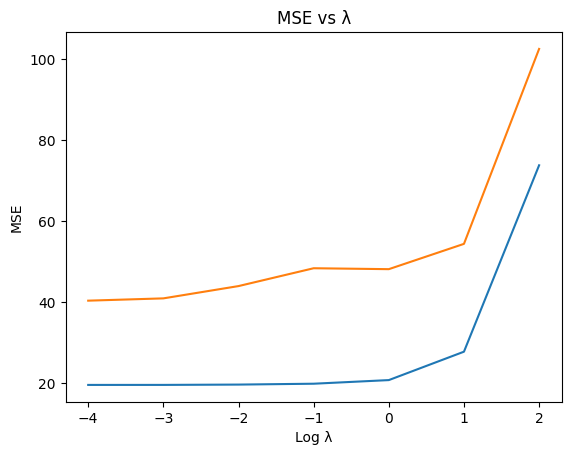

In [16]:
plt.plot([-4,-3,-2,-1,0,1,2], train_MSEs)
plt.plot([-4,-3,-2,-1,0,1,2], test_MSEs)
plt.xlabel('Log λ')
plt.ylabel('MSE')
plt.title('MSE vs λ')
plt.show()


iii) λ is minimized for 0.0001, which indicates that there is no overfitting for a degree 3 polynomial. It is much better than linear, but extremely close to d) iii), which means that the extra hyperparameter does not impact our accuracy significantly in this specific case.

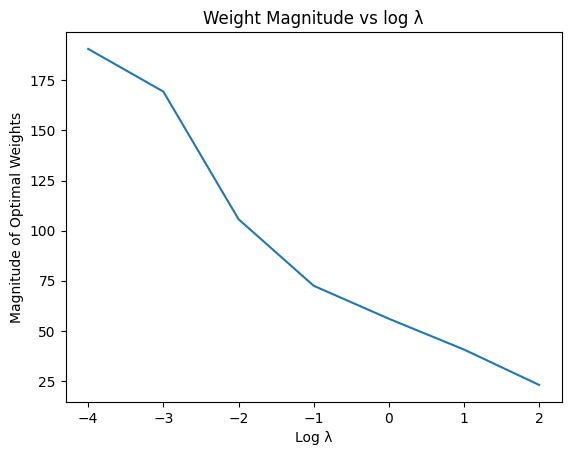

In [17]:
# iv)
magnitudes = [np.linalg.norm(w) for w in optimal_weights]
plt.plot([-4,-3,-2,-1,0,1,2], magnitudes)
plt.xlabel('Log λ')
plt.ylabel('Magnitude of Optimal Weights')
plt.title('Weight Magnitude vs log λ')
plt.show()

In [18]:
# f) i)
from sklearn.model_selection import KFold

Phi_train_p3 = polynomial_features(X_train_np, p=3)
Phi_test_p3 = polynomial_features(X_test_np,  p=3)

print(f"Degree-3 expanded matrix shape: {Phi_train_p3.shape}")

# Define lambda grid and CV setup
lambdas = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100]
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

y_train_np = y_train.values

# 5-Fold Cross-Validation for each lambda
cv_results = {}

for lam in lambdas:
    fold_mses = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(Phi_train_p3)):
        # Split into train and validation folds
        Phi_fold_train, Phi_fold_val = Phi_train_p3[train_idx], Phi_train_p3[val_idx]
        y_fold_train,   y_fold_val   = y_train_np[train_idx],   y_train_np[val_idx]

        # Ridge normal equations: w* = (X^T X + λI)^{-1} X^T y
        d = Phi_fold_train.shape[1]
        I = np.eye(d)
        I[0, 0] = 0   # do NOT regularize the bias term

        w_ridge = np.linalg.inv(Phi_fold_train.T @ Phi_fold_train + lam * I) @ Phi_fold_train.T @ y_fold_train

        # Evaluate on validation fold
        y_val_pred = Phi_fold_val @ w_ridge
        mse = np.mean((y_val_pred - y_fold_val) ** 2)
        fold_mses.append(mse)

    cv_results[lam] = np.mean(fold_mses)

#Report results
print(f"\n{'Lambda':>10}  {'Mean Val MSE':>14}")
print("-" * 28)
for lam, mean_mse in cv_results.items():
    print(f"{lam:>10.4f}  {mean_mse:>14.4f}")

#Best lambda
best_lambda = min(cv_results, key=cv_results.get)
print(f"\nBest λ: {best_lambda} (Mean Val MSE: {cv_results[best_lambda]:.4f})")



Degree-3 expanded matrix shape: (824, 165)



    Lambda    Mean Val MSE
----------------------------
    0.0001         61.2198
    0.0010         60.5532
    0.0100         55.0920
    0.1000         43.6074
    1.0000         38.9655
   10.0000         40.5008
  100.0000         63.6859

Best λ: 1 (Mean Val MSE: 38.9655)


In [19]:
# ii)
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# Retrain on full training set using best lambda
d = Phi_train_p3.shape[1]
I = np.eye(d)
I[0, 0] = 0  # do not regularize bias

w_best = np.linalg.inv(Phi_train_p3.T @ Phi_train_p3 + best_lambda * I) @ Phi_train_p3.T @ y_train_np

# Evaluate on train and test
y_pred_train_cv = Phi_train_p3 @ w_best
y_pred_test_cv  = Phi_test_p3  @ w_best

print(f"Best λ from 5-Fold CV: {best_lambda}")
print(f"\nFinal Model Performance (λ = {best_lambda}):")
print(f"  Train MSE : {mse(y_train_np,y_pred_train_cv):.4f}")
print(f"  Test  MSE : {mse(y_test.values,y_pred_test_cv):.4f}")

Best λ from 5-Fold CV: 1

Final Model Performance (λ = 1):
  Train MSE : 20.5313
  Test  MSE : 50.3145


Surprisingly, the conclusions are different and the regular model actually performs better than the 5-fold on test MSE (and worse on training MSE). This indicates that the p=3 model was not overfitting and adding λ actually hurt performance

iii)
We would have data leakage because we would choose the best lambda for that specific section of data, and not unseen data in general

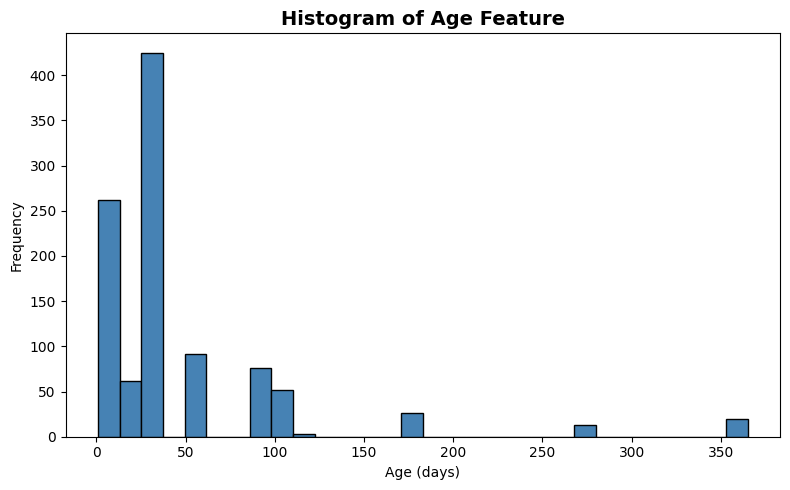

Number of distinct age values: 14
Samples with Age = 28: 425 (41.26%)


In [20]:
# Histogram of Age feature
plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=30, color='steelblue', edgecolor='black')
plt.title('Histogram of Age Feature', fontsize=14, fontweight='bold')
plt.xlabel('Age (days)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Distribution analysis
distinct_ages = df['age'].nunique()
age_counts    = df['age'].value_counts().sort_index()
age28_count   = df[df['age'] == 28].shape[0]
age28_frac    = age28_count / len(df)
skewness      = df['age'].skew()

print(f"Number of distinct age values: {distinct_ages}")
print(f"Samples with Age = 28: {age28_count} ({age28_frac*100:.2f}%)")

In [21]:
age_counts = X_train['age'].value_counts()  # count of each age group
N_train = len(X_train)

# α_n = N / |{i : x_i,8 = x_n,8}| (inverse frequency)
alpha = X_train['age'].map(lambda age: N_train / age_counts[age]).values

most_common_age = age_counts.idxmax() #can't hardcode 28 since we standardized training set
most_rare_age   = age_counts.idxmin()
print(f"Most common age: {most_common_age} → weight = {N_train / age_counts[most_common_age]:.4f}")
print(f"Most rare age:   {most_rare_age}  → weight = {N_train / age_counts[most_rare_age]:.4f}")

X_train_b = np.hstack([np.ones((X_train.shape[0], 1)), X_train.values])
X_test_b  = np.hstack([np.ones((X_test.shape[0],  1)), X_test.values])

A = np.diag(alpha)
w_wls = np.linalg.inv(X_train_b.T @ A @ X_train_b) @ X_train_b.T @ A @ y_train.values

y_pred_train_wls = X_train_b @ w_wls
y_pred_test_wls  = X_test_b  @ w_wls


train_mse_wls = mse(y_train.values, y_pred_train_wls)
test_mse_wls  = mse(y_test.values,  y_pred_test_wls)

print(f"\nWeighted OLS (degree-1):")
print(f"  Train MSE : {train_mse_wls:.4f}")
print(f"  Test  MSE : {test_mse_wls:.4f}")

Most common age: -0.2755058199232769 → weight = 2.3543
Most rare age:   -0.721966121595144  → weight = 412.0000



Weighted OLS (degree-1):
  Train MSE : 137.1660
  Test  MSE : 121.3799


Using Weighted Least Squares significantly hurt both MSEs, however, a practicioner might prefer it because it gives better representation to other ages. Our dataset is basically optimized for age=28 and this model attempts to be more general.

h)
| Model | Training MSE | Test MSE |
| -------- | -------- | -------- |
| Linear    | 110.6449 | 95.9709   |
| Degree 2    | 53.1022 | 55.5825   |
| Degree 3 | 19.5843 | 40.3052 |
| Ridge with best λ| 20.5313| 50.3145|
| Weighted Linear |137.1660 | 121.3799|

I would recommend Degree 3 even though I expected ridge with best λ to perform better. I believe that Degree 3 obtained the best result because it did not significantly overfit the data and had the best test MSE (note that the random split might have influenced that). Regularization is used to prevent overfitting in higher polynomial degree models, effectevely dragging down the norm of the weights and avoiding the characteristic of very high weights causing overfitting. Weighted regression is prefered when the dataset is not representative of your data, having too many repeated data points and only a few of others. 